In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# импорт из библиотеки scipy.optimize
# функции curve_fit
from scipy.optimize import curve_fit


In [2]:
# Ячейка № 2

# задание функции, возвращающей
# абсолютные значения скоростей частиц
# в начальный монет времени
def Init(N, E_System):
    # N - число частиц системы
    # E_System - энергия системы

    V = np.zeros(N)
    V[:] = np.sqrt(E_System / N)

    return V

In [ ]:
# Ячейка № 3

# задание функции,  усредненные
# по ансамблям реализаций значения:
# энергии демона (Demon_Average);
# средней энергии системы на одну частицу (E_System_Average);
# средней скорости частицы (V_Average);
# среднее число принятия испытаний (N_Accept_Average)
def Demon(N, E_System, N_Trial, Velocity, D_V):
    # N - число частиц системы
    # E_System - энергия системы
    # N_Trial - число шагов метода Монте-Карло
    # Velocity - массив, содержащий начальные значения
    #            скоростей частиц
    # D_V - максимальное абсолютное значение
    #       величины изменения скорости
    E_Demon = 0
    V_Total = np.sum(Velocity)
    V_Cum = 0
    E_System_Cum = 0
    E_Demon_Cum = 0
    N_Accept = 0
    for j in range(N_Trial):
        for i in range(N):
            # задание случайного значения
            # величины изменения скорости
            d_v = random.uniform(-1, 1) * D_V
            # случайных выбор номера частицы
            # для изменения ее скорости
            I_Particle = int(random.uniform(0, N))
            # изменение скорости выбранной частицы
            V_Trial = Velocity[I_Particle] + d_v
            # вычисление соответствующего изменения
            # энергии выбранной частицы
            d_E = 0.5 * (V_Trial**2 - Velocity[I_Particle] ** 2)

            if d_E <= E_Demon:
                # если энергия уменьшилась, изменения принимаются
                Velocity[I_Particle] = V_Trial
                V_Total = V_Total + d_v
                N_Accept = N_Accept + 1
                E_Demon = E_Demon - d_E
                E_System = E_System + d_E
            E_Demon_Cum = E_Demon_Cum + E_Demon
            E_System_Cum = E_System_Cum + E_System
            V_Cum = V_Cum + V_Total

    # вычисление усредненных
    # по ансамблям реализаций значений:
    # энергии демона (Demon_Average);
    # средней энергии системы на одну частицу (E_System_Average);
    # средней скорости частицы (V_Average);
    # среднее число принятия испытаний (N_Accept_Average)
    E_Demon_Average = E_Demon_Cum / (N_Trial * N)
    N_Accept_Average = N_Accept / (N_Trial * N)
    E_System_Average = (1 / N) * E_System_Cum / (N_Trial * N)
    V_Average = (1 / N) * V_Cum / (N_Trial * N)

    return E_Demon_Average, E_System_Average, V_Average, N_Accept_Average

In [ ]:
# Ячейка # 4

# вычисление энтропии статистической системы

# инициализация генератора случайных чисел
random.seed()

# задание энергии системы
E_System = 40

# задание числа частиц системы
N = 40

# задание числа шагов метода Монет-Карло
N_Trial = 5 * 10**3

# задание значения максимальной величины
# изменения скорости
D_V = 2 * np.sqrt(2)

# задание начальных значений скорости частиц
Velocity = Init(N, E_System)

# вычисление усредненных
# по ансамблям реализаций значений:
# энергии демона (Demon_Average);
# средней энергии системы на одну частицу (E_System_Average);
# средней скорости частицы (V_Average);
# среднее число принятия испытаний (N_Accept_Average)
[E_Demon_Average, E_System_Average, V_Average, N_Accept_Average] = Demon(
    N, E_System, N_Trial, Velocity, D_V
)

print("Среднее число принятых решений ")
print("об изменении энергии системы = ", N_Accept_Average, "\n")
print("Средняя энергия демона = ", E_Demon_Average, "\n")
print("Средняя энергия системы = ", E_System_Average, "\n")
print("Средняя средняя скорость частиц системы = ", V_Average, "\n")

Среднее число принятых решений 
об изменении энергии системы =  0.507575 

Средняя энергия демона =  0.9457460867499333 

Средняя энергия системы =  0.976356347831243 

Средняя средняя скорость частиц системы =  -0.00394581904095151 



In [ ]:
# Ячейка № 5

# задание функции, возвращающей
# мгновенные значения энергии демона
def Demon_Energy(N, E_system, N_Trial, Velocity, D_V):
    # N - число частиц системы
    # E_System - энергия системы
    # N_Trial - число шагов метода Монте-Карло
    # Velocity - массив, содержащий начальные значения
    #            скоростей частиц
    # D_V - максимальное абсолютное значение
    #       величины изменения скорости

    # инициализация массива, используемого
    # для хранения мгновенных значений
    # энергии демона
    z = np.zeros(N_Trial)
    E_Demon = 0

    # вычисление мгновенных значений энергии демона
    k = 0
    for j in range(N_Trial):
        for i in range(N):
            # задание случайного значения
            # величины изменения скорости
            d_v = random.uniform(-1, 1) * D_V
            # случайных выбор номера частицы
            # для изменения ее скорости
            I_Particle = int(random.uniform(0, N))
            # изменение скорости выбранной частицы
            V_Trial = Velocity[I_Particle] + d_v
            # вычисление соответствующего изменения
            # энергии выбранной частицы
            d_E = 0.5 * (V_Trial**2 - Velocity[I_Particle] ** 2)

            if d_E <= E_Demon:
                # если энергия уменьшилась, изменения принимаются
                Velocity[I_Particle] = V_Trial
                E_Demon = E_Demon - d_E
        z[k] = E_Demon
        k = k + 1
    return z

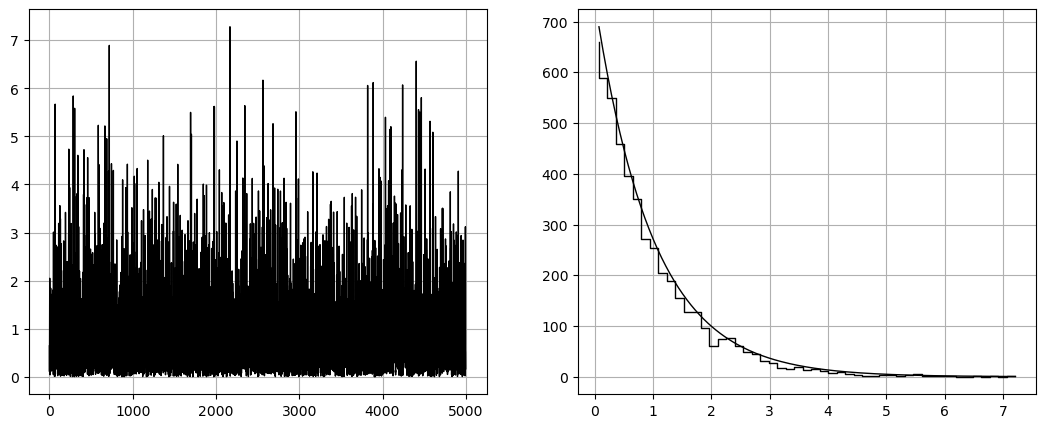

In [ ]:
# Ячейка # 6

# вычисление мгновенных
# значений энергии Демона

# задание энергии системы
E_System = 40

# задание числа частиц системы
N = 40

# задание числа шагов метода Монет-Карло
N_Trial = 5 * 10**3

# задание значения максимальной величины
# изменения скорости
D_V = 2 * np.sqrt(2)

# задание начальных значений скорости частиц
Velocity = Init(N, E_System)

E_Demon = Demon_Energy(N, E_System, N_Trial, Velocity, D_V)

# визуализация последовательности, составленной
# из мгновенных значений энергии демона,
# эмпирической плотности распределения данной последовательности и
# ее аппроксимации

fig = plt.figure(figsize=(13, 11))
# визуализация мгновенных значений энергии демона
ax = plt.subplot(2, 2, 1)
ax.plot(E_Demon, "-k", lw=1)
ax.grid(True)

# вычисление и визуализация
# эмпирической плотности распределения
# последовательности, составленной
# из мгновенных значений энергии демона,
# эмпирической плотности распределения данной последовательности и
# ее аппроксимации
N_bin = 49
xbins = np.arange(
    np.min(E_Demon), np.max(E_Demon), (max(E_Demon) - min(E_Demon)) / N_bin
)

# вычисление эмпирической
# плотности распределения
# энергии демона
H = np.histogram(E_Demon, bins=50)

# вычисление координат
# центров интервалов гистограммы
x = np.zeros(len(H[1]) - 1)
for i in range(len(H[1]) - 1):
    x[i] = (H[1][i] + H[1][i + 1]) / 2


# вычисление коэффициентов a, b, c
# аппроксимации эмпирической
# плотности распределения
# мгновенной  энергии демона
# функцией вида a * sqrt(-b * x)
Coeff = curve_fit(lambda t, a, b: a * np.exp(-b * t), x, H[0])
Сoeff2 = Coeff[0]


# задание функции, возвращающей
# значения аппроксимирующей функции
def func(x, a, b):
    return a * np.exp(-b * x)


# вычисление значений аппроксимирующей функции
x2 = np.linspace(x[0], x[len(x) - 1], 200)
y = func(x2, Сoeff2[0], Сoeff2[1])

# визуализация эмпирической плотности распределения
# аппроксимации функцией вида a * sqrt(-b * x)
ax = plt.subplot(2, 2, 2)
ax.step(x, H[0], "-k", lw=1)
ax.plot(x2, y, "-k", lw=1)
ax.grid(True)

plt.show()